In [1]:
%pip install pandas scikit-learn matplotlib

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import pandas as pd

text_path = "../datasets/openlibrary_urban_texts/urban_books_texts.json"

with open(text_path, "r", encoding="utf-8") as f:
    data = json.load(f)

df_text = pd.DataFrame(data)

print(df_text.shape)
df_text.head()

(250, 3)


,keyword,title,text
0,urban design,Urban design,"Title: Urban design. Author: Cliff Moughtin, J..."
1,urban design,Wuthering Heights,Title: Wuthering Heights. Author: Emily Bronte...
2,urban design,Hans Andersen's Fairy Tales,Title: Hans Andersen's Fairy Tales. Author: Ha...
3,urban design,Alice's Adventures in Wonderland,Title: Alice's Adventures in Wonderland. Autho...
4,urban design,The Canterbury Tales,Title: The Canterbury Tales. Author: Geoffrey ...


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = df_text["text"].tolist()

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=500
)

tfidf_matrix = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (250, 500)


In [4]:
print(feature_names[:50])

['1530' '1612' '1665' '1830' '1900' '22' '24' '56' '8085' 'ab' 'abroad'
 'ackerman' 'adam' 'advanced' 'adventures' 'alex' 'alexander' 'american'
 'andersen' 'anthony' 'applications' 'approaching' 'architectural'
 'architecture' 'architettura' 'arnason' 'arnold' 'art' 'arthur'
 'association' 'author' 'banerjee' 'baruch' 'baselitz' 'baum' 'bento'
 'book' 'brian' 'brown' 'bruno' 'burton' 'byzantine' 'cad' 'calif'
 'canterbury' 'carmona' 'carnegie' 'carpenter' 'carroll' 'case']


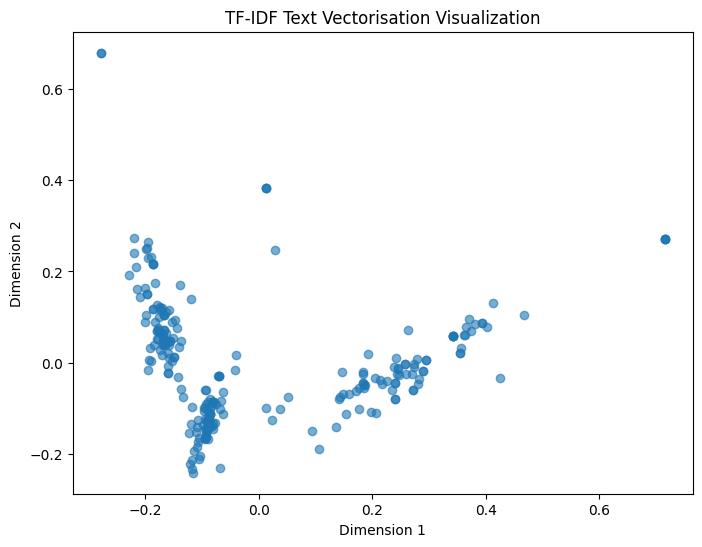

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
text_2d = pca.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(8,6))
plt.scatter(text_2d[:,0], text_2d[:,1], alpha=0.6)

plt.title("TF-IDF Text Vectorisation Visualization")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()

Text vectorisation saved


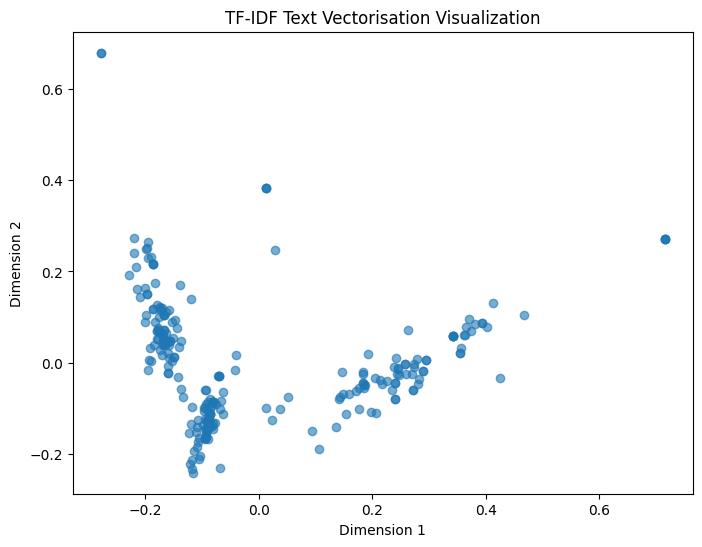

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("../outputs/vectorisation", exist_ok=True)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names
)

tfidf_df.to_csv("../outputs/vectorisation/text_tfidf_vectors.csv", index=False)

plt.figure(figsize=(8,6))
plt.scatter(text_2d[:,0], text_2d[:,1], alpha=0.6)
plt.title("TF-IDF Text Vectorisation Visualization")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.savefig("../outputs/vectorisation/text_tfidf_visualisation.png")

print("Text vectorisation saved")

In [7]:
%pip install gensim

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [9]:
texts = df_text["text"].tolist()

tagged_data = [
    TaggedDocument(words=text.lower().split(), tags=[str(i)])
    for i, text in enumerate(texts)
]

print("Tagged documents:", len(tagged_data))

Tagged documents: 250


In [10]:
doc2vec_model = Doc2Vec(
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    epochs=40
)

doc2vec_model.build_vocab(tagged_data)
doc2vec_model.train(
    tagged_data,
    total_examples=doc2vec_model.corpus_count,
    epochs=doc2vec_model.epochs
)

print("Doc2Vec training finished")

Doc2Vec training finished


In [11]:
doc2vec_vectors = []

for i in range(len(texts)):
    doc2vec_vectors.append(doc2vec_model.dv[str(i)])

print("Doc2Vec vectors:", len(doc2vec_vectors), len(doc2vec_vectors[0]))

Doc2Vec vectors: 250 100


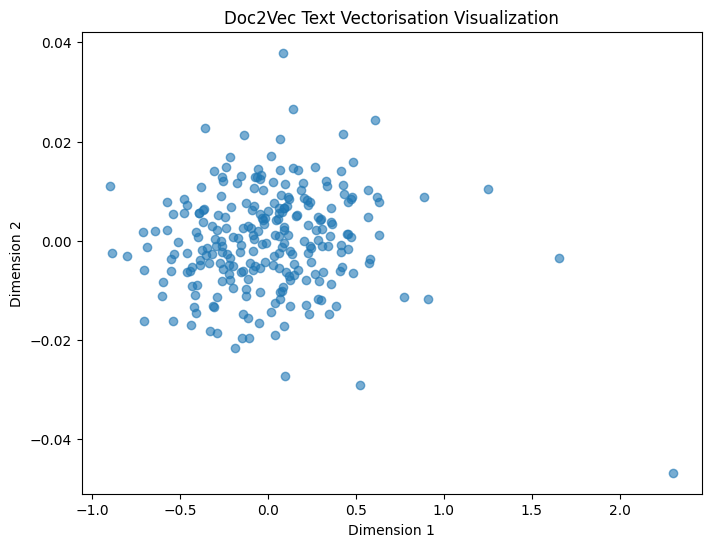

In [12]:
pca = PCA(n_components=2)
doc2vec_2d = pca.fit_transform(doc2vec_vectors)

plt.figure(figsize=(8,6))
plt.scatter(doc2vec_2d[:,0], doc2vec_2d[:,1], alpha=0.6)

plt.title("Doc2Vec Text Vectorisation Visualization")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()

Doc2Vec vectorisation saved


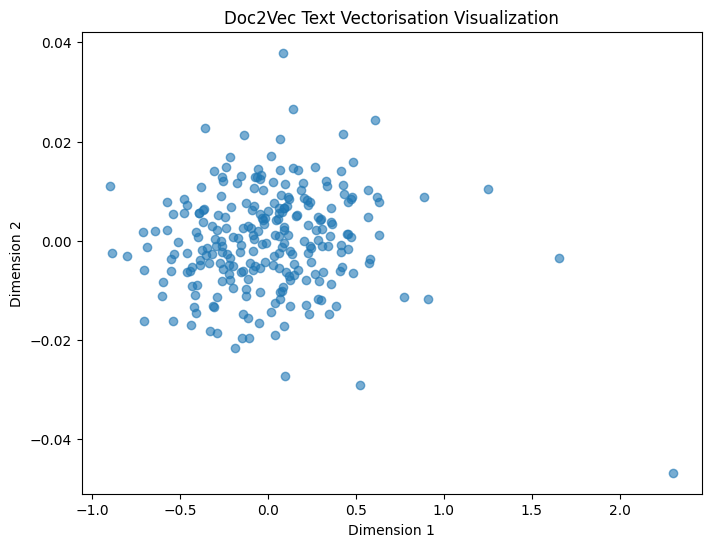

In [13]:
import os
import pandas as pd

os.makedirs("../outputs/vectorisation", exist_ok=True)

doc2vec_df = pd.DataFrame(doc2vec_vectors)
doc2vec_df.to_csv("../outputs/vectorisation/text_doc2vec_vectors.csv", index=False)

plt.figure(figsize=(8,6))
plt.scatter(doc2vec_2d[:,0], doc2vec_2d[:,1], alpha=0.6)
plt.title("Doc2Vec Text Vectorisation Visualization")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.savefig("../outputs/vectorisation/text_doc2vec_visualisation.png")

print("Doc2Vec vectorisation saved")